# Statistics Tutorial Python Part

This is a small notebook that belongs to the statics tutorial. Working along the statistics tutorial, fill out the gaps that are marked with `TODO`. Otherwise, just execute the cells.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Load the Data from the file 'position.npy'

In [3]:
posData = np.load("position.npy")
posDataX = posData[0,:] # x position data is in first row
posDataY = posData[1,:] # y position data is in second row

Plot the position data

(5211.555763524248, 5358.815606494956, 2030.1505685780946, 2289.7977411800057)

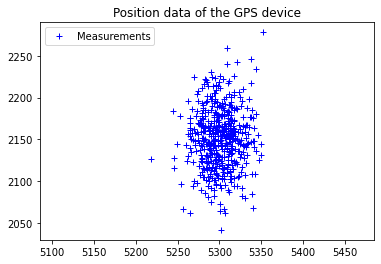

In [4]:
plt.figure(1) # new figure
######## YOUR CODE GOES HERE ###########
plt.plot(TODO) # plot the data
plt.title(TODO) # add a title
plt.legend(TODO) # add a label
########################################
plt.gca().axis('equal') # equal spacing

Compute the expectation value of Max’s position. Plot it in a figure with the data. Useful commands are `np.sum()` and `np.mean()`.

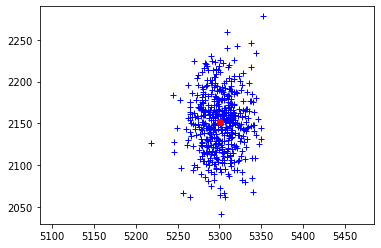

In [5]:
N = posDataX.shape[0] # number of measurements
plt.figure(2)
plt.gca().axis('equal') # equal spacing

######## YOUR CODE GOES HERE ###########
posXEV = TODO # compute the expected value of the x position
posYEV = TODO # compute the expected value of the y position

plt.plot(TODO) # plot the data
plt.plot(TODO) # plot the expected value
########################################


Then compute the variance and the standard deviation of the measurement noise of the x- and y-data. Useful commands are `np.var` and `np.std`.

In [6]:
######## YOUR CODE GOES HERE ###########
posXvar = TODO
posYvar = TODO

posXstd = TODO
posYstd = TODO
########################################

print(f"The variances of the measurement data are \n varX = {posXvar:0.3f} [m^2]\n varY = {posYvar:0.3f} [m^2].")
print(f"The standard deviation of the measurement data are \n stdX = {posXstd:0.3f} [m]\n stdY = {posYstd:0.3f} [m].")



The variances of the measurement data are 
 varX = 392.653 [m^2]
 varY = 1254.078 [m^2].
The standard deviation of the measurement data are 
 stdX = 19.815 [m]
 stdY = 35.413 [m].


Compute the covariance matrix

In [7]:
covMat = TODO

array([[ 393.44026466,   32.60200778],
       [  32.60200778, 1256.59095063]])

From the covariance matrix, plot the 1-sigma confidence ellipsoid.

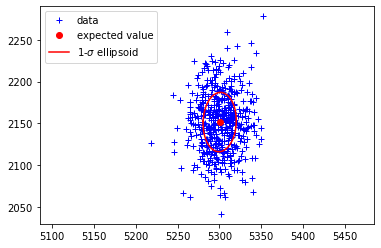

In [8]:
# Get the eigendecomposition of the covariance matrix
D, V = np.linalg.eig(covMat)
# Compute the matrix square root (this holds for real symmetric matrices)
covMatSqrt = V @ np.diag(np.sqrt(D)) @ V.T
# Creat 50 points of a unit circle
xy = np.array([np.cos(np.linspace(0,2*np.pi,50)), np.sin(np.linspace(0,2*np.pi,50))])
# Deform unit circle into confidence ellipse
confEllipse = np.vstack([posXEV, posYEV])[:,np.newaxis] + covMatSqrt @ xy

# create a nice plot
plt.figure(3)
plt.plot(posDataX,posDataY,'+b',label='data') # plot the data
plt.plot(posXEV,posYEV,'ro',label='expected value')
plt.plot(confEllipse[0,:],confEllipse[1,:],'r-', label=r'1-$\sigma$ ellipsoid')
plt.gca().axis('equal') # equal spacing
plt.legend()